# 3C - Precursores: o que antecede o pico do Nino 3.4?

**Pergunta especifica.** Quais variaveis fisicas lideram a SSTA do Nino 3.4 e em que defasagem semanal?

**Objetivo.** Fazer triagem visual e numerica de lags usando apenas a matriz canonica da Fase 3. A metrica de calor acumulado e unica: `dhw_cweek_p90`.

**Justificativa.** A Fase 3 nao compara janelas DHW concorrentes; isso evita dupla contagem da mesma ideia fisica. O DHW publicado agora e C-week acima do P90 diario local.

**Metodologia.** Correla `preditor[t-lag]` com `SSTA_Nino34[t]` em 0..78 semanas. Mapa longitude-lag usa SSTA OISST do Pacifico equatorial 2S-2N; as longitudes 170W-120W marcam a caixa Nino 3.4. O eixo longitudinal e invertido para leitura leste->oeste.

**Saidas.** `phase3C_lag_correlacoes.csv`, `phase3C_precursor_ranking.csv`, `phase3C_mapa_lon_lag.csv`, `phase3C_heatmap_lags.png`, `phase3C_mapa_lon_lag.png`.


In [1]:
import sys; sys.path.insert(0,'.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fase3_utils as u
w=pd.read_csv(u.FEAT/'phase3_indices_semanais.csv',parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
tgt=w['nino34_ssta']; COMMON='1993-01-01'; LAGS=range(0,79)
preds=[c for c in w.columns if c!='nino34_ssta']
def lcf(df,tg,lags): return pd.DataFrame({c:{lag:tg.corr(df[c].shift(lag)) for lag in lags} for c in df.columns})
lc=lcf(w.loc[COMMON:,preds],tgt.loc[COMMON:],LAGS)
lc.rename_axis('lag_semanas').to_csv(u.STATS/'phase3C_lag_correlacoes.csv')
print('Correlacoes defasadas (1993+) calculadas para:',list(lc.columns))

Correlacoes defasadas (1993+) calculadas para: ['d20_m', 'ohc_0_300', 'ohc_0_700', 'wwv', 'tilt_m', 'ssh_m', 'sss', 'dhw_cweek_p90', 'tau_x_proxy_nino34_pa']


In [2]:
rank=pd.DataFrame({'r_max_abs':lc.abs().max(),'lag_do_max_semanas':lc.abs().idxmax()})
rank['r_no_lag_max']=[round(lc.loc[l,v],3) for v,l in zip(rank.index,rank['lag_do_max_semanas'])]
rank=rank.sort_values('r_max_abs',ascending=False)
u.save_table(rank.rename_axis('variavel'),'phase3C_precursor_ranking.csv')
print('RANKING preliminar (variavel | lag do |r| max | r):')
for v,row in rank.iterrows(): print(f'  {v:22s} lag {int(row.lag_do_max_semanas):2d} sem  r={row.r_no_lag_max:+.3f}')

[tabela] data\processed\parquet\statistics\phase3C_precursor_ranking.csv
RANKING preliminar (variavel | lag do |r| max | r):
  tilt_m                 lag  0 sem  r=+0.772
  ssh_m                  lag  6 sem  r=+0.755
  ohc_0_300              lag  6 sem  r=+0.738
  ohc_0_700              lag  6 sem  r=+0.701
  dhw_cweek_p90          lag  0 sem  r=+0.600
  d20_m                  lag 15 sem  r=+0.545
  wwv                    lag 20 sem  r=+0.516
  tau_x_proxy_nino34_pa  lag  1 sem  r=+0.442
  sss                    lag 44 sem  r=+0.247


[figura] data\processed\figures\fase3\phase3C_heatmap_lags.png


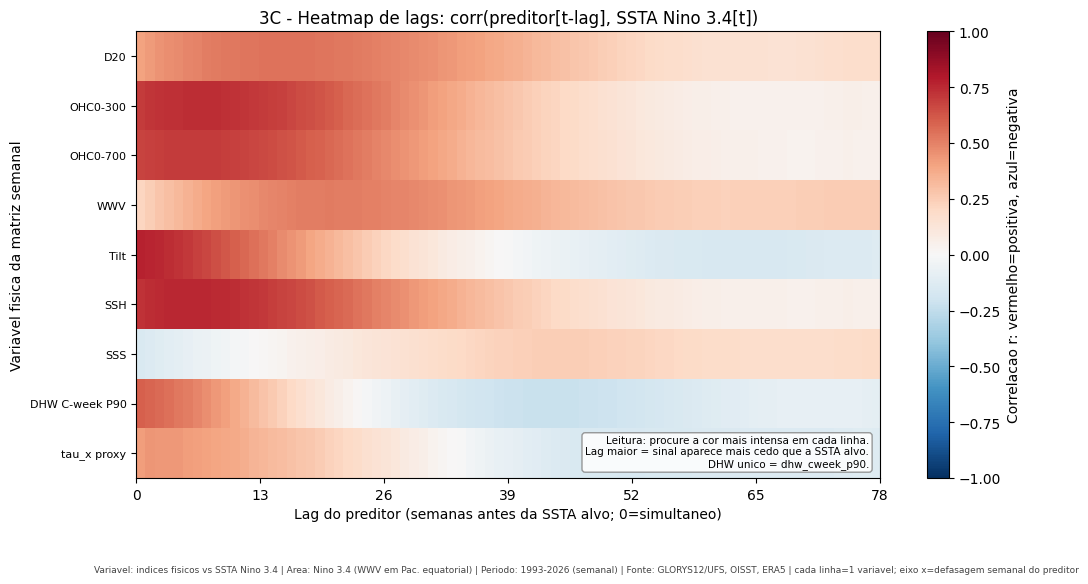

In [3]:
fig,ax=plt.subplots(figsize=(12,5.8))
cols=list(lc.columns)
mat=lc[cols].T.values
im=ax.imshow(mat,aspect='auto',cmap='RdBu_r',vmin=-1,vmax=1,extent=[min(LAGS),max(LAGS),len(cols)-0.5,-0.5])
ax.set_yticks(range(len(cols)))
ax.set_yticklabels([u.var_label(c, short=True) for c in cols],fontsize=8)
ax.set_xticks(range(0,79,13))
ax.set_xlabel('Lag do preditor (semanas antes da SSTA alvo; 0=simultaneo)')
ax.set_ylabel('Variavel fisica da matriz semanal')
ax.set_title('3C - Heatmap de lags: corr(preditor[t-lag], SSTA Nino 3.4[t])')
cb=fig.colorbar(im,ax=ax,label='Correlacao r: vermelho=positiva, azul=negativa')
u.add_note(ax,'Leitura: procure a cor mais intensa em cada linha.\nLag maior = sinal aparece mais cedo que a SSTA alvo.\nDHW unico = dhw_cweek_p90.',loc='lower right')
u.stamp_caption(fig,variavel='indices fisicos vs SSTA Nino 3.4',area='Nino 3.4 (WWV em Pac. equatorial)',periodo='1993-2026 (semanal)',fonte='GLORYS12/UFS, OISST, ERA5',extra='cada linha=1 variavel; eixo x=defasagem semanal do preditor')
u.save_fig(fig,'phase3C_heatmap_lags.png'); plt.show()


[figura] data\processed\figures\fase3\phase3C_mapa_lon_lag.png


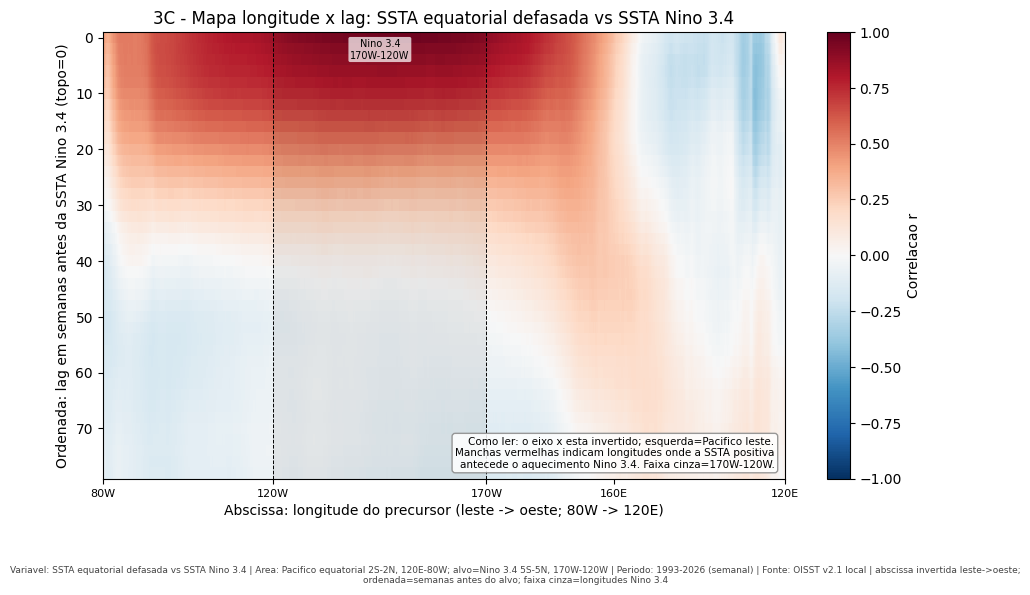

In [4]:
eq=u.load_eqband_weekly().loc[COMMON:]; t=tgt.loc[COMMON:]
eqa,ta=eq.align(t,join='inner',axis=0); tv=ta.values; lags=list(range(0,79,2))
ll=np.full((len(lags),eqa.shape[1]),np.nan)
for i,lag in enumerate(lags):
    sh=eqa.shift(lag).values
    for j in range(eqa.shape[1]):
        x=sh[:,j]; m=np.isfinite(x)&np.isfinite(tv)
        if m.sum()>100: ll[i,j]=np.corrcoef(x[m],tv[m])[0,1]
lon=eqa.columns.values
fig,ax=plt.subplots(figsize=(11,5.8))
pc=ax.pcolormesh(lon,lags,ll,cmap='RdBu_r',vmin=-1,vmax=1,shading='auto')
u.add_nino34_lon_band(ax)
u.format_lon_axis(ax, xlabel='Abscissa: longitude do precursor (leste -> oeste; 80W -> 120E)')
ax.invert_yaxis()
ax.set_ylabel('Ordenada: lag em semanas antes da SSTA Nino 3.4 (topo=0)')
ax.set_title('3C - Mapa longitude x lag: SSTA equatorial defasada vs SSTA Nino 3.4')
fig.colorbar(pc,ax=ax,label='Correlacao r')
u.add_note(ax,'Como ler: o eixo x esta invertido; esquerda=Pacifico leste.\nManchas vermelhas indicam longitudes onde a SSTA positiva\nantecede o aquecimento Nino 3.4. Faixa cinza=170W-120W.',loc='lower right')
u.stamp_caption(fig,variavel='SSTA equatorial defasada vs SSTA Nino 3.4',area='Pacifico equatorial 2S-2N, 120E-80W; alvo=Nino 3.4 5S-5N, 170W-120W',periodo='1993-2026 (semanal)',fonte='OISST v2.1 local',extra='abscissa invertida leste->oeste; ordenada=semanas antes do alvo; faixa cinza=longitudes Nino 3.4')
pd.DataFrame(ll,index=lags,columns=lon).rename_axis('lag_semanas').to_csv(u.STATS/'phase3C_mapa_lon_lag.csv')
u.save_fig(fig,'phase3C_mapa_lon_lag.png'); plt.show()


**Leitura do 3C.** O ranking preliminar (ver saida numerica) e liderado pelo bloco de recarga - **tilt (lag 0), SSH/OHC (~6 sem), D20 (~15 sem), WWV (~20 sem)** - todos series do Nino 3.4 exceto WWV (Pac. equatorial). O mapa lon x lag mostra a inclinacao oeste->leste: anomalias no Pacifico central-oeste antecedem a caixa Nino 3.4, coerente com Kelvin/adveccao. **Nada aqui e significancia** - isso e 3D.